# Análise Diabetes - Regressão Linear

### Descobrir as 2 colunas mais impactantes na progressão da diabetes
### Propor um tamanho de treinamento e random state melhores para a precisão do treinamento
### MSE - Quanto menor, melhor
### R² - Quanto mais próximo de 1, melhor

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
dados = load_diabetes()

df = pd.DataFrame(dados.data, columns=dados.feature_names)
display(df.head(5))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Alvo Previsto,Alvo Gabarito
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220,139.547558,219.0
211,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,179.517208,70.0
72,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,134.038756,202.0
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,291.417029,230.0
73,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362,123.789659,111.0
...,...,...,...,...,...,...,...,...,...,...,...,...
255,0.001751,-0.044642,-0.065486,-0.005670,-0.007073,-0.019476,0.041277,-0.039493,-0.003301,0.007207,115.011800,153.0
90,0.012648,-0.044642,-0.025607,-0.040099,-0.030464,-0.045155,0.078093,-0.076395,-0.072133,0.011349,78.955842,98.0
57,-0.027310,-0.044642,-0.063330,-0.050427,-0.089630,-0.104340,0.052322,-0.076395,-0.056153,-0.067351,81.560873,37.0
391,-0.023677,-0.044642,-0.069797,-0.064199,-0.059359,-0.050478,0.019187,-0.039493,-0.089133,-0.050783,54.379973,63.0


'MSE: 2900.193628'

'R2: 0.452603'

,Dado Preditivo,Coeficiente
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


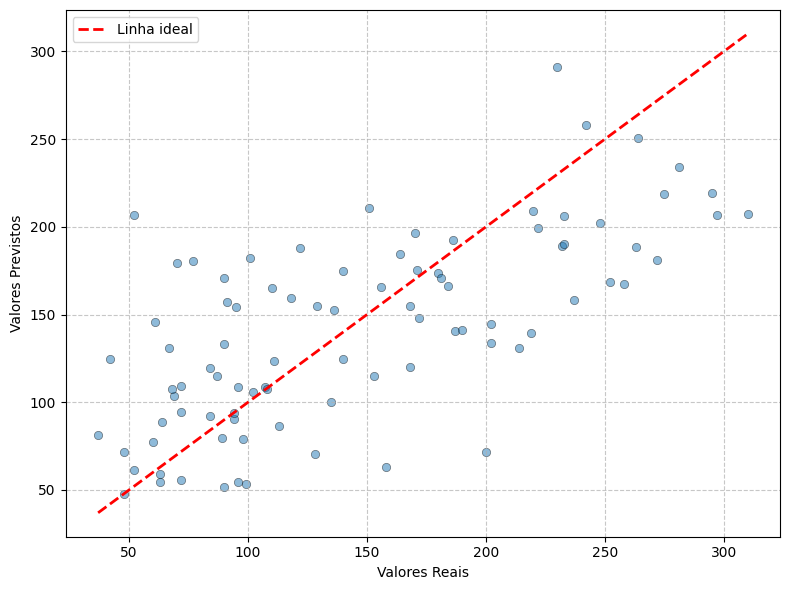

In [42]:
# Separar a tabela em dados preditivos e alvos

df["Alvo"] = dados.target
dados_preditivos = df[dados.feature_names]

alvos = df["Alvo"]

# Separar os dados preditivos e alvos em dados de treinamento e dados de teste
dados_preditivos_treino, dados_preditivos_teste, alvos_treino, alvos_teste = train_test_split(dados_preditivos, alvos, test_size=0.2, random_state=42)

linear = LinearRegression()
linear.fit(dados_preditivos_treino, alvos_treino)

alvos_previsao = linear.predict(dados_preditivos_teste)

df_previsao = dados_preditivos_teste
df_previsao["Alvo Previsto"] = alvos_previsao 
df_previsao["Alvo Gabarito"] = alvos_teste 

display(df_previsao)

mse = mean_squared_error(alvos_teste, alvos_previsao)
r2 = r2_score(alvos_teste, alvos_previsao)


display(f'MSE: {mse:4f}')
display(f"R2: {r2:4f}")

coeficientes = pd.DataFrame({
    "Dado Preditivo": dados.feature_names,
    "Coeficiente": linear.coef_
})

display(coeficientes)    

plt.figure(figsize=(8, 6))

plt.scatter(alvos_teste, alvos_previsao, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([alvos_teste.min(), alvos_teste.max()], [alvos_teste.min(), alvos_teste.max()], 'r--', lw=2, label="Linha ideal")

plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()